In [1]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import seaborn as sns

from afolu.assets.constants import LABEL_LIST
from afolu.assets.emissions import build_dataset, generate_model_objects

/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/munch/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
ZONE = "PER+Coronel Portillo"

In [3]:
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [4]:
areas = pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
transitions = pd.read_csv(out_path / "small" / "transition" / "cube" / f"{ZONE}.csv")

In [5]:
df_area = pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv").set_index("label").T
df_area.index = df_area.index.astype(int)

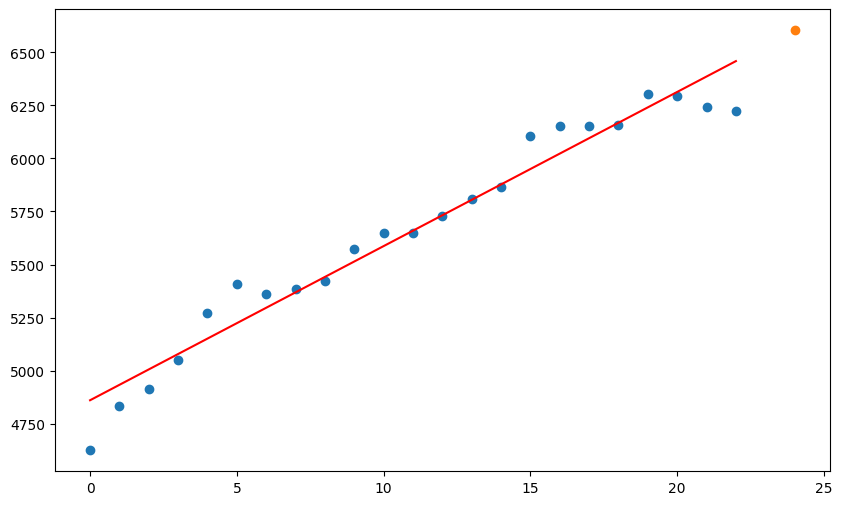

In [6]:
X = df_area.index.to_numpy().reshape(-1, 1)
y = df_area["settlements"].to_numpy()

coef = np.polyfit(X.flatten(), y, 1)
yhat = np.polyval(coef, X.flatten())

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, y)
ax.plot(X, yhat, color="red")
ax.scatter([24], np.polyval(coef, [24]))

Label forests_mangroves not found in the DataFrame.


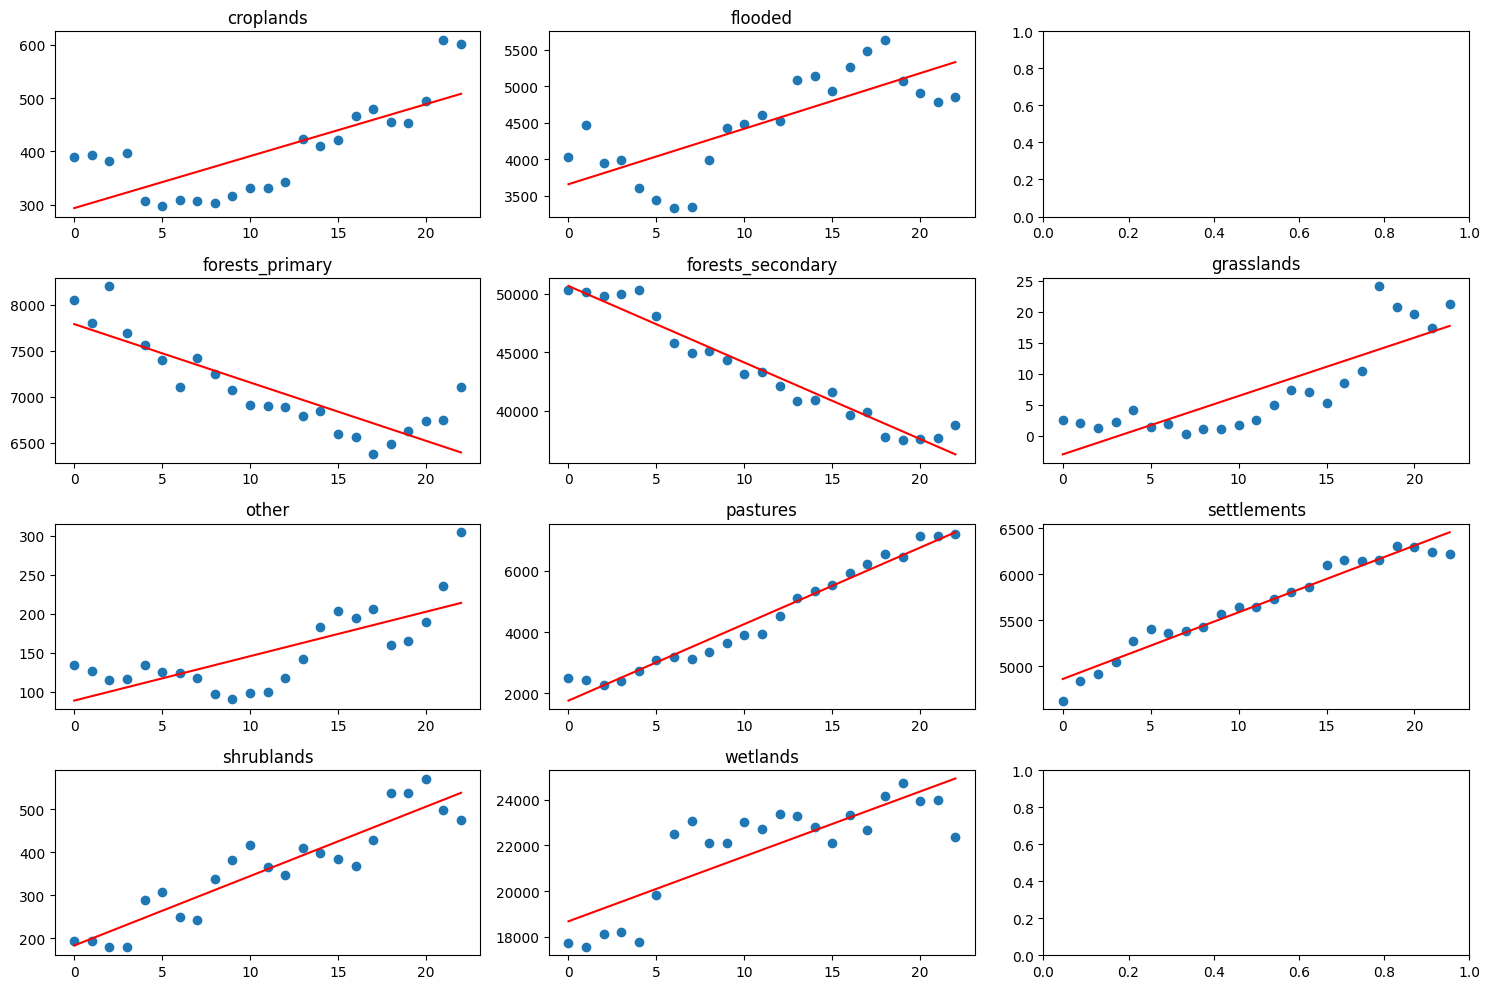

In [7]:
fig, ax = plt.subplots(4, 3, figsize=(15, 10))

yhats, coefs = [], {}
X = df_area.index.to_numpy().reshape(-1, 1)
for label, ax in zip(LABEL_LIST, ax.flatten(), strict=False):
    try:
        y = df_area[label].to_numpy()
    except KeyError:
        print(f"Label {label} not found in the DataFrame.")
        continue

    coef = np.polyfit(X.flatten(), y, 1)
    yhat = np.polyval(coef, X.flatten())

    coefs[label] = coef
    yhats.append(yhat)

    ax.scatter(X, y)
    ax.plot(X, yhat, color="red")

    ax.set_title(label)
fig.tight_layout()

In [8]:
def derive_coef(x: float, orig_coef: np.ndarray, scale: float) -> np.ndarray:
    new_slope = orig_coef[0] * scale
    new_intersect = np.polyval(orig_coef, x) - new_slope * x
    return np.array([new_slope, new_intersect])


def predict_scaled(x: float, orig_coef: np.ndarray, scale: float) -> float:
    coef = derive_coef(x[0], orig_coef, scale)
    return np.polyval(coef, x)

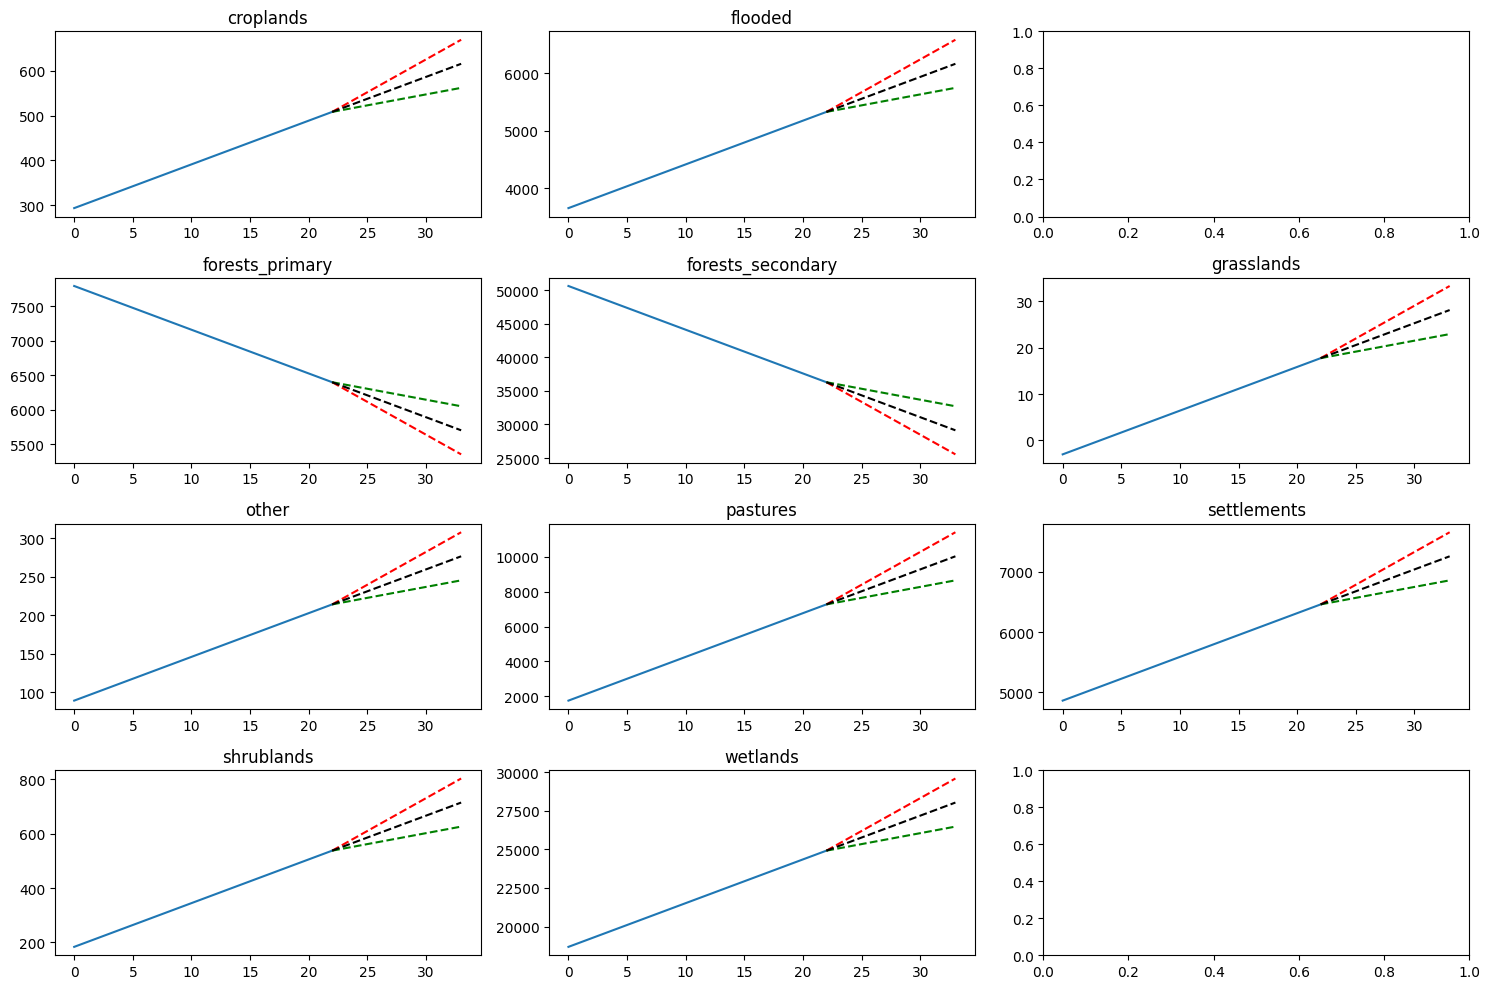

In [9]:
x = X.flatten()
x_future = np.arange(22, 34)

fig, axes = plt.subplots(4, 3, figsize=(15, 10))

for label, ax in zip(LABEL_LIST, axes.flatten(), strict=False):
    if label not in df_area.columns:
        continue

    coef = coefs[label]
    yhat = np.polyval(coef, x)
    pred_fast = predict_scaled(x_future, coef, 1.5)
    pred_slow = predict_scaled(x_future, coef, 0.5)
    pred_normal = predict_scaled(x_future, coef, 1.0)

    ax.plot(x, yhat)
    ax.plot(x_future, pred_fast, linestyle="--", c="red")
    ax.plot(x_future, pred_slow, linestyle="--", c="green")
    ax.plot(x_future, pred_normal, linestyle="--", c="black")
    ax.set_title(label)

fig.tight_layout()

In [113]:
examples, _, model_afolu, regions, time_periods = generate_model_objects()

/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:533: UserWarning: Path '/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2025-07-14T20;33;06.626840' not found. It will not be created.
  warnings.warn(msg)
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/core/model_attributes.py:6684: UserWarning: 

                        MISSIONSEARCHNOTE: As of 2023-10-06, there is a temporary solution 
                        implemeted in ModelAttributes.get_variable_to_simplex_group_dictionary() 
                        to ensure that transition probability rows are enforced on a simplex.
                        
                        
                        FIX THIS ASAP TO DERIVE PROPERLY.
                        
                        
  warnings.warn(
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/core/model_

In [169]:
def emissions_small(
    areas: pd.DataFrame,
    transitions: pd.DataFrame,
    *,
    iso: str,
) -> pd.DataFrame:
    # Initialize SISEPUEDE objects
    examples, _, model_afolu, regions, time_periods = generate_model_objects()

    temp = areas.set_index("label")

    areas_frac = (
        temp
        .div(temp.sum(axis=0), axis=1)
        .reset_index(names="label")
    )
    display(areas_frac)

    # run model
    dict_ursa_data = {
        "areas": areas,
        "areas_frac": areas_frac,
        "transitions": transitions,
    }

    df_in = build_dataset(
        examples,
        iso,
        model_afolu,
        regions,
        time_periods,
        dict_ursa_data=dict_ursa_data,
        path_ssp_data=data_path / "initial" / "sisepuede_pipeline_data",
    )

    return model_afolu(
        df_in,
    ).set_index("time_period")

In [170]:
def predict_emissions_scaled(
    df_area: pd.DataFrame,
    df_transitions: pd.DataFrame,
    *,
    n_years_forward: int,
    coefs: dict[str, np.ndarray],
    scale: float,
) -> pd.DataFrame:
    x_future = np.arange(23, 23 + n_years_forward)

    preds, labels = [], []
    for label in LABEL_LIST:
        if label not in coefs:
            continue
        coef = coefs[label]
        pred = predict_scaled(x_future, coef, scale)
        preds.append(pred)
        labels.append(label)

    preds = np.array(preds)
    preds = pd.DataFrame(preds, index=labels, columns=x_future).T
    df_area_pred = pd.concat([df_area, preds], axis=0).T.reset_index(names="label")

    mean_transitions = (
        df_transitions
        .set_index("time_period")
        .loc[17:]
        .mean(axis=0)
        .to_frame()
        .T
        .reset_index(names="time_period")
    )

    transitions_extended = df_transitions.copy()
    for i in range(n_years_forward):
        temp = mean_transitions.copy()
        temp["time_period"] = [i + 22]
        transitions_extended = pd.concat([transitions_extended, temp], axis=0, ignore_index=True)

    return emissions_small(df_area_pred, transitions_extended, iso=ZONE.split("+")[0]), df_area_pred, transitions_extended

In [171]:
res_normal, area_normal, transition_normal = predict_emissions_scaled(
    df_area,
    transitions,
    n_years_forward=10,
    coefs=coefs,
    scale=1.0,
)
# res_fast, area_fast, transition_fast = predict_emissions_scaled(
#     df_area,
#     transitions,
#     n_years_forward=10,
#     coefs=coefs,
#     scale=5,
# )

/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:533: UserWarning: Path '/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/out/sisepuede_run_2025-07-14T21;23;31.969655' not found. It will not be created.
  warnings.warn(msg)
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/core/model_attributes.py:6684: UserWarning: 

                        MISSIONSEARCHNOTE: As of 2023-10-06, there is a temporary solution 
                        implemeted in ModelAttributes.get_variable_to_simplex_group_dictionary() 
                        to ensure that transition probability rows are enforced on a simplex.
                        
                        
                        FIX THIS ASAP TO DERIVE PROPERLY.
                        
                        
  warnings.warn(
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/core/model_

,label,0,1,2,3,4,5,6,7,8,...,23,24,25,26,27,28,29,30,31,32
0,croplands,0.004426,0.004473,0.004344,0.004512,0.003499,0.003377,0.003523,0.003488,0.003448,...,0.005890,0.006001,0.006112,0.006223,0.006334,0.006445,0.006556,0.006667,0.006777,0.006888
1,flooded,0.045733,0.050781,0.044917,0.045353,0.040913,0.039137,0.037835,0.038084,0.045394,...,0.061478,0.062344,0.063210,0.064076,0.064942,0.065808,0.066674,0.067540,0.068406,0.069272
2,forests_primary,0.091496,0.088648,0.093275,0.087480,0.086052,0.084093,0.080861,0.084431,0.082378,...,0.072014,0.071294,0.070574,0.069854,0.069134,0.068414,0.067694,0.066974,0.066254,0.065534
3,forests_secondary,0.572083,0.569948,0.566402,0.567674,0.571507,0.546549,0.520778,0.510948,0.512642,...,0.405329,0.397916,0.390503,0.383090,0.375677,0.368265,0.360852,0.353439,0.346026,0.338613
4,grasslands,0.000029,0.000023,0.000014,0.000026,0.000048,0.000016,0.000022,0.000004,0.000012,...,0.000212,0.000223,0.000234,0.000244,0.000255,0.000266,0.000276,0.000287,0.000298,0.000308
5,other,0.001530,0.001441,0.001306,0.001322,0.001530,0.001421,0.001410,0.001341,0.001109,...,0.002498,0.002562,0.002627,0.002692,0.002756,0.002821,0.002886,0.002950,0.003015,0.003079
6,pastures,0.028477,0.027801,0.025889,0.027333,0.031085,0.035038,0.036210,0.035466,0.038099,...,0.085477,0.088325,0.091173,0.094022,0.096870,0.099718,0.102567,0.105415,0.108263,0.111112
7,settlements,0.052580,0.054958,0.055871,0.057395,0.059936,0.061470,0.060955,0.061233,0.061653,...,0.074265,0.075091,0.075917,0.076744,0.077570,0.078396,0.079222,0.080049,0.080875,0.081701
8,shrublands,0.002197,0.002203,0.002046,0.002049,0.003279,0.003502,0.002846,0.002764,0.003845,...,0.006297,0.006480,0.006663,0.006847,0.007030,0.007213,0.007396,0.007580,0.007763,0.007946
9,wetlands,0.201449,0.199724,0.205937,0.206855,0.202152,0.225397,0.255559,0.262241,0.251421,...,0.286541,0.289763,0.292986,0.296209,0.299432,0.302654,0.305877,0.309100,0.312323,0.315546


/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:2210: FutureWarning: DataFrame.interpolate with method=bfill is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .interpolate(method = "bfill")
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:2211: FutureWarning: DataFrame.interpolate with method=ffill is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .interpolate(method = "ffill")
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:2210: FutureWarning: DataFrame.interpolate with method=bfill is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .interpolate(method = "bfill")
/Users/rodolfofigueroa/Documents/afolu/.venv/lib/python3.11/site-packages/sisepuede/utilities/_toolbox.py:2211: FutureWarning: Dat

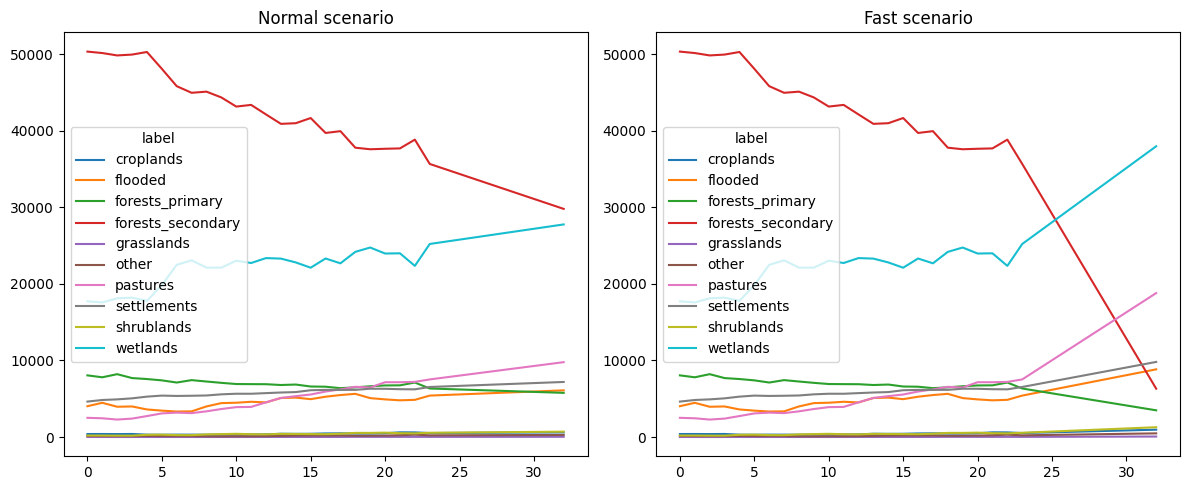

In [168]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
area_normal.set_index("label").T.plot(ax=ax[0])
area_fast.set_index("label").T.plot(ax=ax[1])

ax[0].set_title("Normal scenario")
ax[1].set_title("Fast scenario")

fig.tight_layout()

In [159]:
sequestration_columns = [
    "emission_co2e_co2_lndu_biomass_sequestration_grasslands",
    "emission_co2e_co2_lndu_biomass_sequestration_other",
    "emission_co2e_co2_lndu_biomass_sequestration_pastures",
    "emission_co2e_co2_lndu_biomass_sequestration_settlements",
    "emission_co2e_co2_lndu_biomass_sequestration_shrublands",
    "emission_co2e_co2_lndu_biomass_sequestration_wetlands",
    "emission_co2e_subsector_total_frst",
]

In [160]:
fast_sequestration = res_fast[sequestration_columns].sum(axis=1)
normal_sequestration = res_normal[sequestration_columns].sum(axis=1)

In [163]:
(res_normal - res_fast).abs().max().max()

np.float64(4.06545911602052e-07)

<Axes: xlabel='time_period'>

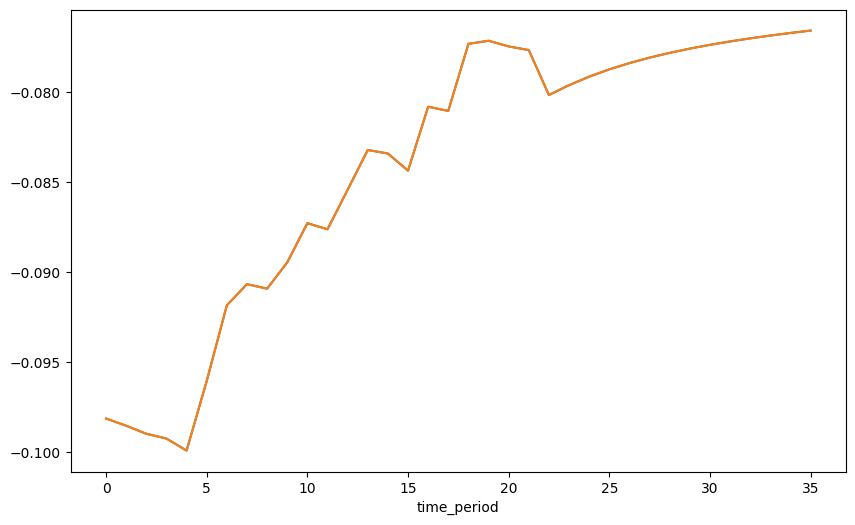

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
normal_sequestration.plot(ax=ax, label="Normal Sequestration")
fast_sequestration.plot(ax=ax, label="Fast Sequestration")

In [ ]:
fast